# 11 — Advanced EDA Block 7: Predictive Models

**PACE Phase**: Analyze (advanced)
**Objective**: build predictive models to anticipate crime volume,
predict the probability of a case being cleared, and identify
co-occurrence and re-victimization patterns.

**Input**: `data/processed/crimes_features.parquet`

**Questions we answer**:
- Q7.1 — 7-day crime volume forecast (Prophet)
- Q7.2 — Predictive clearance model (Random Forest)
- Q7.3 — Spatio-temporal co-occurrence
- Q7.4 — Re-victimization patterns

**Tools used and rationale**:
- **Prophet** (Meta): time series model for forecasting crime
  volume. Chosen over ARIMA because it natively handles weekly and
  annual seasonality, is robust to outliers, and doesn't require
  the data to be stationary
- **scikit-learn** (Random Forest, Logistic Regression): classification
  models for predicting the probability of a case being cleared.
  Random Forest chosen for its robustness, interpretability via
  feature importance, and ability to handle categorical and numeric variables
  without complex preprocessing
- **pandas** for building the spatio-temporal windows
  in the Q7.3 and Q7.4 analyses

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Module for Q7.1
from prophet import Prophet

#Modules for Q7.2
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_info_columns', 200)

df = pd.read_parquet('../../data/processed/crimes_features.parquet')
df.head()

,DR_NO,Date Rptd,DATE OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,hour_occ,year,month,day_of_week,hour_bins,age_group,crime_category,report_delay,is_domestic
0,1307355,2010-02-20,2010-02-20,13,Newton,1385,2,900,VIOLATION OF COURT ORDER,0913 1814 2000,48.0,M,H,501.0,SINGLE FAMILY DWELLING,0.0,No Weapon,AA,Adult Arrest,900.0,300 E GAGE AV,33.9825,-118.2695,13,2010,2,Saturday,Afternoon,Adult,person,0,False
1,11401303,2010-09-13,2010-09-12,14,Pacific,1485,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0329,NaN,M,W,101.0,STREET,0.0,No Weapon,IC,Invest Cont,740.0,SEPULVEDA BL,33.9599,-118.3962,0,2010,9,Sunday,Night,NaN,property,1,False
2,70309629,2010-08-09,2010-08-09,13,Newton,1324,2,946,OTHER MISCELLANEOUS CRIME,0344,NaN,M,H,103.0,ALLEY,0.0,No Weapon,IC,Invest Cont,946.0,1300 E 21ST ST,34.0224,-118.2524,15,2010,8,Monday,Afternoon,NaN,other,0,False
3,90631215,2010-01-05,2010-01-05,6,Hollywood,646,2,900,VIOLATION OF COURT ORDER,1100 0400 1402,47.0,F,W,101.0,STREET,102.0,HAND GUN,IC,Invest Cont,900.0,CAHUENGA BL,34.1016,-118.3295,1,2010,1,Tuesday,Night,Adult,person,0,False
4,100100501,2010-01-03,2010-01-02,1,Central,176,1,122,"RAPE, ATTEMPTED",0400,47.0,F,H,103.0,ALLEY,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,122.0,8TH ST,34.0387,-118.2488,21,2010,1,Saturday,Late Night,Adult,person,1,False


## 2. Q7.1 — 7-day crime volume forecast

We build a time series model to forecast the expected crime
volume for the next 7 days, using the entire dataset history
(2010–2023) as training data and 2024 as the test period.

**Objective**: assess whether the daily crime volume is predictable
and with what accuracy. Target: MAPE (Mean Absolute Percentage Error) < 15%.

**Tool**: Prophet (Meta) — natively handles weekly and
annual seasonality, outliers, and holidays.

In [2]:
daily_crimes = (
    df
    .groupby('DATE OCC')
    .size()
    .reset_index(name='y')
    .rename(columns={'DATE OCC': 'ds'})
)
daily_crimes['ds'] = pd.to_datetime(daily_crimes['ds'])
daily_crimes = daily_crimes.sort_values('ds')
print(daily_crimes.head(10))
print(f'Shape: {daily_crimes.shape}')

          ds     y
0 2010-01-01  2354
1 2010-01-02   535
2 2010-01-03   539
3 2010-01-04   559
4 2010-01-05   548
5 2010-01-06   532
6 2010-01-07   550
7 2010-01-08   605
8 2010-01-09   631
9 2010-01-10   618
Shape: (5478, 2)


In [3]:
train = daily_crimes[daily_crimes['ds'] < '2023-01-01']
test = daily_crimes[daily_crimes['ds'] >= '2023-01-01']

print(f'Train: {train.shape} — from {train["ds"].min().date()} to {train["ds"].max().date()}')
print(f'Test: {test.shape} — from {test["ds"].min().date()} to {test["ds"].max().date()}')

Train: (4748, 2) — dal 2010-01-01 al 2022-12-31
Test: (730, 2) — dal 2023-01-01 al 2024-12-30


In [4]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

model.fit(train)
print('Model trained.')

08:45:24 - cmdstanpy - INFO - Chain [1] start processing
08:45:25 - cmdstanpy - INFO - Chain [1] done processing


Modello addestrato.


In [5]:
future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

             ds        yhat  yhat_lower  yhat_upper
5468 2024-12-21  754.181062  599.475653  902.601666
5469 2024-12-22  729.355641  556.516539  871.585726
5470 2024-12-23  748.338332  597.932325  895.503908
5471 2024-12-24  736.663361  575.638581  881.566320
5472 2024-12-25  746.442380  588.906552  886.855090
5473 2024-12-26  742.549794  578.784576  883.937239
5474 2024-12-27  796.264767  637.020091  949.344079
5475 2024-12-28  760.059689  601.896714  909.998361
5476 2024-12-29  735.156130  563.249077  880.245502
5477 2024-12-30  754.003292  590.091838  901.807760


In [6]:
test_2023 = test[test['ds'].dt.year == 2023].copy()
forecast_2023 = forecast[forecast['ds'].dt.year == 2023][['ds', 'yhat']].copy()

merged = test_2023.merge(forecast_2023, on='ds')
merged['mape'] = abs(merged['y'] - merged['yhat']) / merged['y'] * 100

mape = merged['mape'].mean()
print(f'MAPE on 2023: {mape:.2f}%')
print(f'Average real crimes 2023: {merged["y"].mean():.0f}')
print(f'Average predicted crimes 2023: {merged["yhat"].mean():.0f}')

MAPE sul 2023: 10.74%
Media crimini reali 2023: 636
Media crimini previsti 2023: 682


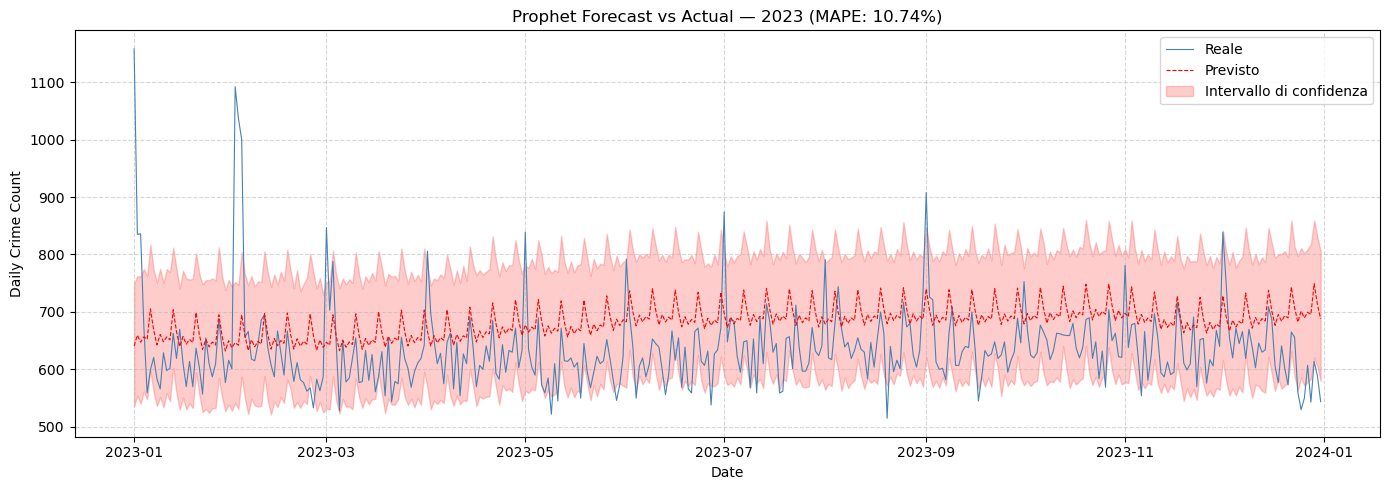

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(merged['ds'], merged['y'], label='Actual', color='steelblue', linewidth=0.8)
ax.plot(merged['ds'], merged['yhat'], label='Predicted', color='red', linewidth=0.8, linestyle='--')
ax.fill_between(
    forecast[forecast['ds'].dt.year == 2023]['ds'],
    forecast[forecast['ds'].dt.year == 2023]['yhat_lower'],
    forecast[forecast['ds'].dt.year == 2023]['yhat_upper'],
    alpha=0.2, color='red', label='Confidence interval'
)
ax.set_title(f'Prophet Forecast vs Actual — 2023 (MAPE: {mape:.2f}%)')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Crime Count')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../../outputs/11_advanced_eda_block2/35_prophet_forecast_2023.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations Q7.1 — 7-day crime volume forecast (Prophet)

**Main result**: MAPE on 2023 = **10.74%** — below the 15%
threshold set as the objective. The model can predict
the daily crime volume with an average error of 10.74%.

**General trend**: the predicted line (red) correctly follows
the overall crime trend in 2023, capturing the
weekly seasonality (regular oscillations) and the average level.

**Systematic overestimation**: the predicted line tends to sit above
the actual one — the model slightly overestimates crime volume.
This is consistent with the fact that it was trained on years
(2010-2022) with average volumes higher than 2023,
which shows the structural decline already documented in previous blocks.

**Confidence interval**: the pink band is wide but well calibrated —
the actual line almost always falls within it. This means
the model is honest about its own uncertainty: when it says the value
will be within a certain range, the actual value indeed falls there.

**Anomalous peaks**: the peaks in the actual line (early January, February)
likely correspond to particular days (New Year's, special
events) that the model can't capture without
holiday information.

**2024**: the drop in the actual line at the end of the chart is consistent with
the 2024 dataset artifact already documented in previous blocks
(incomplete dataset). The predicted line stays stable because Prophet
extrapolates the historical trend without knowing about this anomaly.

**Methodological note**: the model is trained on data aggregated
at the citywide level. Forecasts for a single LAPD area or for a
crime category would require separate models and would
involve higher MAPE due to lower volumes.

## 3. Q7.2 — Predictive clearance model

We build a classification model that predicts the probability
of a case being cleared (cleared vs not cleared) based on the features
available at the time of the report.

**Objective**: identify which crime characteristics most
influence the probability of case resolution, and build a
model that can support investigation prioritization.

**Target**: `Status Desc` column — cleared cases (Adult Arrest, Juv Arrest,
Adult Other, Juv Other) vs not cleared (Invest Cont, UNK)

**Features used**:
- `AREA NAME` — LAPD area where the crime occurred
- `crime_category` — macro-category (Person/Property/Other)
- `Weapon Desc` — type of weapon used
- `Vict Sex` — victim's sex
- `age_group` — victim's age group
- `Vict Descent` — victim's descent
- `report_delay` — days between the crime and the report
- `hour_bins` — time slot of the crime
- `day_of_week` — day of the week

**Tool**: Random Forest — chosen for its robustness, ability to handle
categorical and numeric variables, and interpretability via feature importance.

In [8]:
# Column selection
q72_df = df[['AREA NAME', 'crime_category', 'Weapon Desc', 'Vict Sex',
             'age_group', 'Vict Descent', 'report_delay',
             'hour_bins', 'day_of_week', 'Status Desc']].copy()

# Create target
cleared_statuses = ['Adult Arrest', 'Juv Arrest', 'Adult Other', 'Juv Other']
q72_df['is_cleared'] = q72_df['Status Desc'].isin(cleared_statuses).astype(int)
q72_df = q72_df.drop(columns=['Status Desc'])

# Remove NaN
q72_df = q72_df.dropna()

print(q72_df.shape)
print(q72_df['is_cleared'].value_counts())

(2447032, 10)
is_cleared
0    1848185
1     598847
Name: count, dtype: int64


In [9]:
feature_cols = ['AREA NAME', 'crime_category', 'Weapon Desc', 'Vict Sex',
                'age_group', 'Vict Descent', 'report_delay',
                'hour_bins', 'day_of_week']

X = pd.get_dummies(q72_df[feature_cols], drop_first=True)
y = q72_df['is_cleared']

print(f'Features: {X.shape[1]}')
print(f'Samples: {X.shape[0]}')

Features: 138
Campioni: 2447032


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,} samples')
print(f'Test: {X_test.shape[0]:,} samples')

Train: 1,957,625 campioni
Test: 489,407 campioni


In [11]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)
print('Model trained.')

Modello addestrato.


In [12]:
y_pred = model_rf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Not Cleared', 'Cleared']))

              precision    recall  f1-score   support

 Not Cleared       0.92      0.68      0.78    369637
     Cleared       0.45      0.82      0.58    119770

    accuracy                           0.71    489407
   macro avg       0.69      0.75      0.68    489407
weighted avg       0.81      0.71      0.73    489407



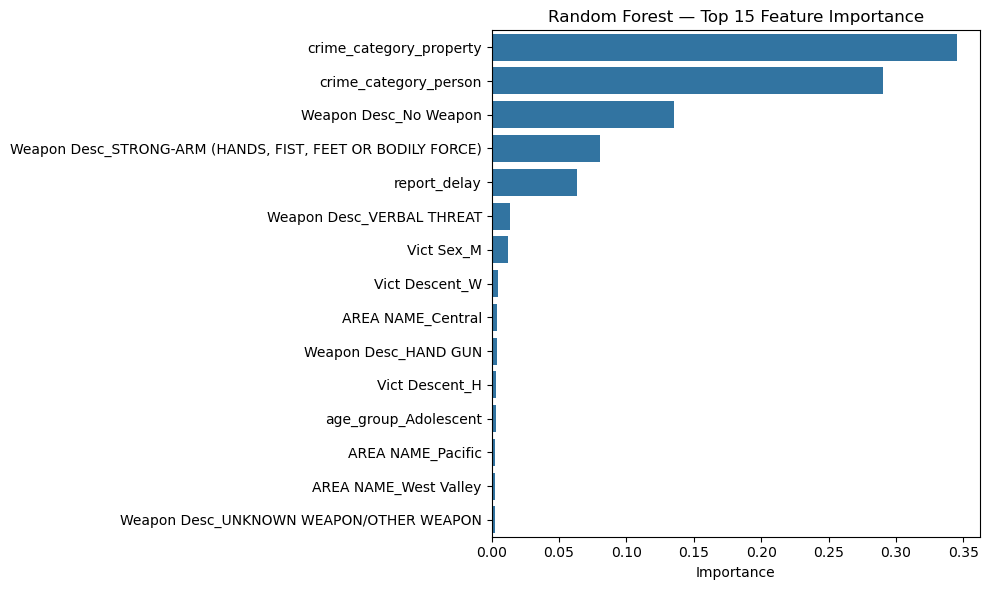

In [13]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', ax=ax)
ax.set_title('Random Forest — Top 15 Feature Importance')
ax.set_xlabel('Importance')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../../outputs/11_advanced_eda_block2/36_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Q7.3 — Spatio-temporal co-occurrence

We analyze whether there are significant associations between crime
types that occur in the same geographic area within a defined
time window (48 hours).

**Objective**: identify patterns of the type "if crime A occurs
in an area, crime B is likely to also occur in the same
area within 48 hours". These patterns can inform proactive
prevention strategies.

**Method**: Association Rules

**Spatio-temporal window**: same LAPD area, within 48 hours.

In [14]:
q73_df = df[['AREA NAME', 'DATE OCC', 'Crm Cd Desc']].copy()
q73_df['DATE OCC'] = pd.to_datetime(q73_df['DATE OCC'])
q73_df['time_window'] = q73_df['DATE OCC'].dt.floor('2D')
q73_df['transaction_id'] = q73_df['AREA NAME'] + '_' + q73_df['time_window'].astype(str)

print(q73_df.head(10))
print(f'Unique transactions: {q73_df["transaction_id"].nunique():,}')

   AREA NAME   DATE OCC                                        Crm Cd Desc  \
0     Newton 2010-02-20                           VIOLATION OF COURT ORDER   
1    Pacific 2010-09-12  VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...   
2     Newton 2010-08-09                          OTHER MISCELLANEOUS CRIME   
3  Hollywood 2010-01-05                           VIOLATION OF COURT ORDER   
4    Central 2010-01-02                                    RAPE, ATTEMPTED   
5    Central 2010-01-04           SHOPLIFTING - PETTY THEFT ($950 & UNDER)   
6    Central 2010-01-07                              BURGLARY FROM VEHICLE   
7    Central 2010-01-08     ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT   
8    Central 2010-01-09     ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT   
9    Central 2010-01-06  THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...   

  time_window        transaction_id  
0  2010-02-20     Newton_2010-02-20  
1  2010-09-12    Pacific_2010-09-12  
2  2010-08-09     Newton_20

In [15]:
transactions = (
    q73_df
    .groupby('transaction_id')['Crm Cd Desc']
    .apply(list)
    .tolist()
)

print(f'Number of transactions: {len(transactions):,}')
print(f'Example transaction: {transactions[0]}')

Numero transazioni: 56,961
Esempio transazione: ['CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)', 'BATTERY - SIMPLE ASSAULT', 'THEFT OF IDENTITY', 'THEFT OF IDENTITY', 'THEFT OF IDENTITY', 'THEFT OF IDENTITY', 'INTIMATE PARTNER - SIMPLE ASSAULT', 'BATTERY WITH SEXUAL CONTACT', 'VEHICLE - STOLEN', 'THEFT OF IDENTITY', 'THEFT OF IDENTITY', 'THEFT OF IDENTITY', 'VEHICLE - STOLEN', 'THEFT OF IDENTITY', 'THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD', 'CRIMINAL THREATS - NO WEAPON DISPLAYED', 'THEFT OF IDENTITY', 'THEFT OF IDENTITY', 'VANDALISM - MISDEAMEANOR ($399 OR UNDER)', 'THEFT OF IDENTITY', 'BATTERY - SIMPLE ASSAULT', 'CRIMINAL THREATS - NO WEAPON DISPLAYED', 'OTHER MISCELLANEOUS CRIME', 'BURGLARY FROM VEHICLE', 'CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)', 'THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)', 'ATTEMPTED ROBBERY', 'BURGLARY', 'CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)', 'THEFT OF IDENTITY', 'THEFT OF IDENTITY', 'BATTERY

In [16]:
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
te_df = pd.DataFrame(te_array, columns=te.columns_)
print(f'Matrix shape: {te_df.shape}')
print(te_df.head(3))

Shape matrice: (56961, 143)
   ABORTION/ILLEGAL  ARSON  ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER  \
0             False  False                                         False   
1             False  False                                         False   
2             False  False                                         False   

   ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT  ATTEMPTED ROBBERY  \
0                                            True               True   
1                                            True              False   
2                                            True              False   

   BATTERY - SIMPLE ASSAULT  BATTERY ON A FIREFIGHTER  \
0                      True                     False   
1                      True                     False   
2                      True                     False   

   BATTERY POLICE (SIMPLE)  BATTERY WITH SEXUAL CONTACT  \
0                    False                         True   
1                    False     

In [17]:
frequent_itemsets = apriori(
    te_df,
    min_support=0.3,
    use_colnames=True
)
print(f'Frequent itemsets found: {len(frequent_itemsets)}')
print(frequent_itemsets.sort_values('support', ascending=False).head(10))

Itemset frequenti trovati: 20754
      support                                           itemsets
21   0.963993                                 (VEHICLE - STOLEN)
4    0.940644                            (BURGLARY FROM VEHICLE)
16   0.932726               (THEFT PLAIN - PETTY ($950 & UNDER))
1    0.931567                         (BATTERY - SIMPLE ASSAULT)
19   0.917786  (VANDALISM - FELONY ($400 & OVER, ALL CHURCH V...
109  0.909447          (BURGLARY FROM VEHICLE, VEHICLE - STOLEN)
62   0.901740       (BATTERY - SIMPLE ASSAULT, VEHICLE - STOLEN)
200  0.901599  (VEHICLE - STOLEN, THEFT PLAIN - PETTY ($950 &...
3    0.901354                                         (BURGLARY)
211  0.888994  (VANDALISM - FELONY ($400 & OVER, ALL CHURCH V...


In [18]:
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.8
)
rules = rules.sort_values('lift', ascending=False)
print(f'Rules found: {len(rules)}')
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Regole trovate: 428101
                                              antecedents  \
360497  (CRIMINAL THREATS - NO WEAPON DISPLAYED, INTIM...   
347940  (CRIMINAL THREATS - NO WEAPON DISPLAYED, INTIM...   
354275  (CRIMINAL THREATS - NO WEAPON DISPLAYED, INTIM...   
347998  (CRIMINAL THREATS - NO WEAPON DISPLAYED, INTIM...   
354214  (CRIMINAL THREATS - NO WEAPON DISPLAYED, INTIM...   
255292  (CRIMINAL THREATS - NO WEAPON DISPLAYED, INTIM...   
255233  (CRIMINAL THREATS - NO WEAPON DISPLAYED, INTIM...   
335428  (CRIMINAL THREATS - NO WEAPON DISPLAYED, INTIM...   
237716  (CRIMINAL THREATS - NO WEAPON DISPLAYED, INTIM...   
254991  (CRIMINAL THREATS - NO WEAPON DISPLAYED, INTIM...   

                                              consequents   support  \
360497  (VEHICLE - STOLEN, BATTERY - SIMPLE ASSAULT, R...  0.310107   
347940  (VEHICLE - STOLEN, BATTERY - SIMPLE ASSAULT, R...  0.312723   
354275  (VEHICLE - STOLEN, BATTERY - SIMPLE ASSAULT, R...  0.312301   
347998  (VEHICLE - ST

In [19]:
rules_filtered = rules[
    (rules['antecedents'].apply(lambda x: len(x)) <= 2) &
    (rules['consequents'].apply(lambda x: len(x)) == 1) &
    (rules['lift'] > 1.05)
].sort_values('lift', ascending=False)

print(f'Filtered rules: {len(rules_filtered)}')
print(rules_filtered[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15))

Regole filtrate: 123
                                           antecedents  \
2                                    (BRANDISH WEAPON)   
369  (ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAUL...   
370  (CRIMINAL THREATS - NO WEAPON DISPLAYED, ROBBERY)   
388       (INTIMATE PARTNER - SIMPLE ASSAULT, ROBBERY)   
125            (INTIMATE PARTNER - AGGRAVATED ASSAULT)   
439  (ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAUL...   
387  (INTIMATE PARTNER - SIMPLE ASSAULT, ASSAULT WI...   
438  (VANDALISM - MISDEAMEANOR ($399 OR UNDER), ROB...   
525  (VIOLATION OF RESTRAINING ORDER, VEHICLE - STO...   
287  (VIOLATION OF RESTRAINING ORDER, BATTERY - SIM...   
251                (BATTERY - SIMPLE ASSAULT, ROBBERY)   
249  (BATTERY - SIMPLE ASSAULT, ASSAULT WITH DEADLY...   
535        (BRANDISH WEAPON, BATTERY - SIMPLE ASSAULT)   
20                    (VIOLATION OF RESTRAINING ORDER)   
435  (VANDALISM - FELONY ($400 & OVER, ALL CHURCH V...   

                                          conseque

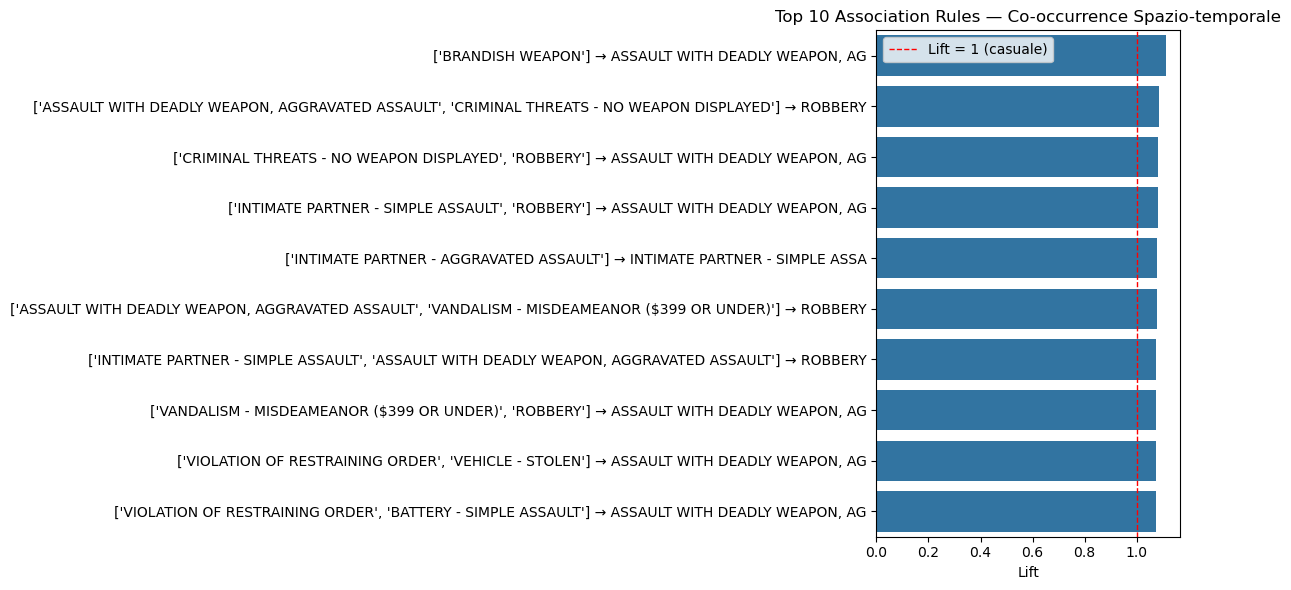

In [20]:
top_rules = rules_filtered.head(10).copy()
top_rules['rule'] = top_rules.apply(
    lambda x: f"{list(x['antecedents'])} → {list(x['consequents'])[0][:30]}",
    axis=1
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_rules, x='lift', y='rule', ax=ax)
ax.set_title('Top 10 Association Rules — Spatio-temporal Co-occurrence')
ax.set_xlabel('Lift')
ax.set_ylabel('')
ax.axvline(x=1.0, color='red', linestyle='--', linewidth=1, label='Lift = 1 (random)')
ax.legend()
plt.tight_layout()
plt.savefig('../../outputs/11_advanced_eda_block2/37_association_rules.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations Q7.3 — Spatio-temporal co-occurrence

**Results**: 123 association rules identified with lift > 1.05
and simple antecedents (≤ 2 crimes). The strongest rules show
associations between violent crimes:

- Brandish Weapon → Aggravated Assault (lift 1.11)
- Intimate Partner Aggravated Assault → Intimate Partner Simple Assault (lift 1.08)
- Violation of Restraining Order → Aggravated Assault (lift 1.07)

**Critical limitation — why this analysis is not being considered**:

The model aggregates crimes at the **LAPD area** level (a geographic
unit of several km²) within the same 48 hours. This means that a rule like
"Intimate Partner Aggravated Assault → Intimate Partner Simple Assault"
doesn't necessarily imply a real connection between the two events —
they could have occurred in completely different families and locations
within the same area, with no causal relationship at all.

A meaningful co-occurrence analysis would require working
with precise address- or block-level coordinates (50-100 meters),
not LAPD-area level. The coordinates in the dataset are obfuscated
to the block centroid (~100m precision), as documented in the
project limitations, which in any case makes it impossible to distinguish
events that occurred in adjacent residences.

Lift values very close to 1 (range 1.05-1.11) confirm that the associations
found are statistically marginal and not actionable for
operational planning.

**Conclusion**: the Q7.3 results are not used in the
project's conclusions for the methodological reasons described above.

## 5. Q7.4 — Re-victimization patterns

We identify repeat victimization patterns by analyzing the
concentration of crimes at the same address or block within
30-, 60-, and 90-day time windows.

**Objective**: pinpoint addresses or areas where the same victim
or the same location is hit repeatedly — the so-called
"repeat victims" and "hot places". These patterns allow us to
identify high-risk situations where early preventive
intervention could break the victimization cycle.

**Method**: group crimes by address (`LOCATION`) and
calculate how many addresses record more than one crime within
30-, 60-, and 90-day windows.

**Methodological note**: the analysis is at the address/block level,
not at the individual victim level — the dataset doesn't contain a
unique victim identifier that would allow tracking the same person
over time.

**Note — Q7.4 not implemented**:

The re-victimization pattern analysis by address was
dropped for two reasons:

1. **Redundancy with Block 6**: identifying repeatedly hit
   locations is conceptually equivalent to the geographic hotspot
   analysis already carried out in Q6.1 (grid hotspot map) and Q6.2
   (hotspot persistence over time). Adding an address-level analysis
   would not produce significant incremental insight.

2. **Data limitation**: the coordinates in the dataset are obfuscated
   to the block centroid (~100m precision), making the distinction
   between "same address" and "same 500m×500m cell" less meaningful
   than it seems. Additionally, the dataset doesn't contain a
   unique victim identifier, preventing re-victimization
   of a person from being distinguished from re-victimization of a location.